# Processing of a resting-state EEG dataset for sleep deprivation

Bad channels are interpolated

## PRE PROCESSING

#### The intention is to provide epochs(4 seconds) to the machine and try predicting if the case is sleep deprivation or normal sleep.

In [1]:
from matplotlib import pyplot as plt
import os
import pandas as pd
import numpy as np
from scipy import signal
import mne
import mne_icalabel
from mne.preprocessing import ICA
from autoreject import Ransac  
from mne_icalabel import label_components
%matplotlib inline

In [2]:
# lists to collect data
X_list = []
y_list = []
data_NS_list =[]
data_SD_list =[]
n_epochs = 0
for i in range(1, 72):
    if i == 28 or i== 1 or i== 44 or i==39 or i==43:
        continue  # Skip participants due to missing data
    for j in range(1, 3):
        
        #Define file path
        file_path = f'D:\\BCI\\TASKS\\Task-8\\ds004902_data\\sub-{i:02d}\\ses-{j}\\eeg\\sub-{i:02d}_ses-{j}_task-eyesopen_eeg.set'#The d indicates that the value is a decimal integer, while the 02 specifies that the output should be padded with leading zeros if necessary to reach a width of two characters.
        epochs_file = f'D:\\BCI\\TASKS\\Task-8\\processed_epochs\\sub-{i:02d}_ses-{j}_epochs.fif'  # Path to save/load processed epochs
        
        
        if os.path.exists(epochs_file):
            print(f"Loading processed epochs from {epochs_file}")
            epochs = mne.read_epochs(epochs_file, preload=True)
        else:
            print(f"\nProcessing: {file_path}\n")

            #Define EEG channels
            eeg_channels = ["Fp1", "AF3", "AF7", "Fz", "F1", "F3", "F5", "F7","FC1", "FC3", "FC5", "FT7","Cz", "C1", "C3", "C5", "T7","CP1", "CP3", "CP5", "TP7", "TP9","Pz", "P1", "P3", "P5", "P7","PO3", "PO7", "Oz", "O1","Fpz", "Fp2", "AF4", "AF8","F2", "F4", "F6", "F8","FC2", "FC4", "FC6", "FT8","C2", "C4", "C6", "T8","CPz", "CP2", "CP4", "CP6","TP8", "TP10","P2", "P4", "P6", "P8","POz", "PO4", "PO8", "O2"]
            
            #Load EEG data
            raw = mne.io.read_raw_eeglab(file_path, preload=True)
            eeg_raw=raw.pick(mne.pick_channels(raw.info['ch_names'], include=eeg_channels))
            
            #Montage setting
            montage = mne.channels.make_standard_montage('standard_1020')
            eeg_raw.set_montage(montage)

            #Filtering
            eeg_raw.filter(1., 40.)#, fir_design='firwin')

            #Average Referencing
            eeg_raw.set_eeg_reference('average')

            #EPOCHING
            epochs = mne.make_fixed_length_epochs(eeg_raw, duration=4.0, overlap=0.0,preload=True)

            #RANSAC for bad channel detection
            ransac = Ransac(verbose=False, n_jobs=1)
            ransac.fit(epochs)
            epochs.info['bads'].extend(ransac.bad_chs_)   

            #interpolate bad channels
            epochs.interpolate_bads(reset_bads=True)
            
            #ICA for artifact removal
            ica = mne.preprocessing.ICA(n_components=20, method='infomax', fit_params=dict(extended=True), random_state=42, max_iter=1000)
            ica.fit(epochs)

            ic_labels = label_components(epochs, ica, method='iclabel')
            exclude_idx = []
            for idx, label in enumerate(ic_labels["labels"]):
                if label not in ["brain","other","muscle artifact"] and ic_labels["y_pred_proba"][idx] > 0.5:
                    exclude_idx.append(idx)

            ica.apply(epochs,exclude= exclude_idx)           

            # Save processed epochs
            os.makedirs(os.path.dirname(epochs_file), exist_ok=True) #creates the necessary directories for the file path if they don't exist.
            epochs.save(epochs_file, overwrite=True)
            print(f"Saved processed epochs to {epochs_file}")

        if j==1:
            labels = 0
        elif j==2:
            labels = 1
        labels = pd.DataFrame({'label': [labels]*len(epochs)})
        
        # Extract data and labels
        data = epochs.get_data()  # shape: (n_epochs, n_channels, n_times)

        #if (i == 39 or i == 43) and j == 2:
        #    data = signal.decimate(data, 10, axis=2) # Downsample by a factor of 10 to match time points.


        epoch_labels = labels['label'].values 

        data_continuous = np.hstack(data) # stacking is done to reconstruct the data, concatination can also be used 
        raw_reconstructed = mne.io.RawArray(data_continuous, epochs.info) #provided into  
        
        if i <= 71:  
            X_list.append(data)
            y_list.append(epoch_labels)

        if j==1:
            data_NS_list.append(data_continuous)
        elif j==2:
            data_SD_list.append(data_continuous)

# After the loop, concatenate into arrays
X= np.concatenate(X_list, axis=0)
y = np.concatenate(y_list, axis=0)
data_SD = data_SD_list
data_NS = data_NS_list

Loading processed epochs from D:\BCI\TASKS\Task-8\processed_epochs\sub-02_ses-1_epochs.fif
Reading D:\BCI\TASKS\Task-8\processed_epochs\sub-02_ses-1_epochs.fif ...


    Found the data of interest:
        t =       0.00 ...    3998.00 ms
        0 CTF compensation matrices available
Not setting metadata
75 matching events found
No baseline correction applied
0 projection items activated
Creating RawArray with float64 data, n_channels=61, n_times=150000
    Range : 0 ... 149999 =      0.000 ...   299.998 secs
Ready.
Loading processed epochs from D:\BCI\TASKS\Task-8\processed_epochs\sub-02_ses-2_epochs.fif
Reading D:\BCI\TASKS\Task-8\processed_epochs\sub-02_ses-2_epochs.fif ...
    Found the data of interest:
        t =       0.00 ...    3998.00 ms
        0 CTF compensation matrices available


C:\Users\suvan\AppData\Local\Temp\ipykernel_11812\3668736409.py:19: RuntimeWarning: This filename (D:\BCI\TASKS\Task-8\processed_epochs\sub-02_ses-1_epochs.fif) does not conform to MNE naming conventions. All epochs files should end with -epo.fif, -epo.fif.gz, _epo.fif or _epo.fif.gz
  epochs = mne.read_epochs(epochs_file, preload=True)
C:\Users\suvan\AppData\Local\Temp\ipykernel_11812\3668736409.py:19: RuntimeWarning: This filename (D:\BCI\TASKS\Task-8\processed_epochs\sub-02_ses-2_epochs.fif) does not conform to MNE naming conventions. All epochs files should end with -epo.fif, -epo.fif.gz, _epo.fif or _epo.fif.gz
  epochs = mne.read_epochs(epochs_file, preload=True)


Not setting metadata
75 matching events found
No baseline correction applied
0 projection items activated
Creating RawArray with float64 data, n_channels=61, n_times=150000
    Range : 0 ... 149999 =      0.000 ...   299.998 secs
Ready.
Loading processed epochs from D:\BCI\TASKS\Task-8\processed_epochs\sub-03_ses-1_epochs.fif
Reading D:\BCI\TASKS\Task-8\processed_epochs\sub-03_ses-1_epochs.fif ...
    Found the data of interest:
        t =       0.00 ...    3998.00 ms
        0 CTF compensation matrices available
Not setting metadata
75 matching events found
No baseline correction applied
0 projection items activated
Creating RawArray with float64 data, n_channels=61, n_times=150000
    Range : 0 ... 149999 =      0.000 ...   299.998 secs
Ready.
Loading processed epochs from D:\BCI\TASKS\Task-8\processed_epochs\sub-03_ses-2_epochs.fif
Reading D:\BCI\TASKS\Task-8\processed_epochs\sub-03_ses-2_epochs.fif ...
    Found the data of interest:
        t =       0.00 ...    3998.00 ms
      

C:\Users\suvan\AppData\Local\Temp\ipykernel_11812\3668736409.py:19: RuntimeWarning: This filename (D:\BCI\TASKS\Task-8\processed_epochs\sub-03_ses-1_epochs.fif) does not conform to MNE naming conventions. All epochs files should end with -epo.fif, -epo.fif.gz, _epo.fif or _epo.fif.gz
  epochs = mne.read_epochs(epochs_file, preload=True)
C:\Users\suvan\AppData\Local\Temp\ipykernel_11812\3668736409.py:19: RuntimeWarning: This filename (D:\BCI\TASKS\Task-8\processed_epochs\sub-03_ses-2_epochs.fif) does not conform to MNE naming conventions. All epochs files should end with -epo.fif, -epo.fif.gz, _epo.fif or _epo.fif.gz
  epochs = mne.read_epochs(epochs_file, preload=True)


...

Creating RawArray with float64 data, n_channels=61, n_times=150000
    Range : 0 ... 149999 =      0.000 ...   299.998 secs
Ready.
Loading processed epochs from D:\BCI\TASKS\Task-8\processed_epochs\sub-70_ses-2_epochs.fif
Reading D:\BCI\TASKS\Task-8\processed_epochs\sub-70_ses-2_epochs.fif ...
    Found the data of interest:
        t =       0.00 ...    3998.00 ms
        0 CTF compensation matrices available
Not setting metadata
75 matching events found
No baseline correction applied
0 projection items activated


C:\Users\suvan\AppData\Local\Temp\ipykernel_11812\3668736409.py:19: RuntimeWarning: This filename (D:\BCI\TASKS\Task-8\processed_epochs\sub-70_ses-2_epochs.fif) does not conform to MNE naming conventions. All epochs files should end with -epo.fif, -epo.fif.gz, _epo.fif or _epo.fif.gz
  epochs = mne.read_epochs(epochs_file, preload=True)


Creating RawArray with float64 data, n_channels=61, n_times=150000
    Range : 0 ... 149999 =      0.000 ...   299.998 secs
Ready.
Loading processed epochs from D:\BCI\TASKS\Task-8\processed_epochs\sub-71_ses-1_epochs.fif
Reading D:\BCI\TASKS\Task-8\processed_epochs\sub-71_ses-1_epochs.fif ...
    Found the data of interest:
        t =       0.00 ...    3998.00 ms
        0 CTF compensation matrices available
Not setting metadata
75 matching events found
No baseline correction applied
0 projection items activated
Creating RawArray with float64 data, n_channels=61, n_times=150000
    Range : 0 ... 149999 =      0.000 ...   299.998 secs
Ready.
Loading processed epochs from D:\BCI\TASKS\Task-8\processed_epochs\sub-71_ses-2_epochs.fif
Reading D:\BCI\TASKS\Task-8\processed_epochs\sub-71_ses-2_epochs.fif ...


C:\Users\suvan\AppData\Local\Temp\ipykernel_11812\3668736409.py:19: RuntimeWarning: This filename (D:\BCI\TASKS\Task-8\processed_epochs\sub-71_ses-1_epochs.fif) does not conform to MNE naming conventions. All epochs files should end with -epo.fif, -epo.fif.gz, _epo.fif or _epo.fif.gz
  epochs = mne.read_epochs(epochs_file, preload=True)
C:\Users\suvan\AppData\Local\Temp\ipykernel_11812\3668736409.py:19: RuntimeWarning: This filename (D:\BCI\TASKS\Task-8\processed_epochs\sub-71_ses-2_epochs.fif) does not conform to MNE naming conventions. All epochs files should end with -epo.fif, -epo.fif.gz, _epo.fif or _epo.fif.gz
  epochs = mne.read_epochs(epochs_file, preload=True)


    Found the data of interest:
        t =       0.00 ...    3998.00 ms
        0 CTF compensation matrices available
Not setting metadata
75 matching events found
No baseline correction applied
0 projection items activated
Creating RawArray with float64 data, n_channels=61, n_times=150000
    Range : 0 ... 149999 =      0.000 ...   299.998 secs
Ready.


In [3]:
len(data_SD), len(data_NS)
data_SD[0].shape, data_NS[0].shape

((61, 150000), (61, 150000))

In [6]:
import numpy as np

# 1. Find the shortest recording length in BOTH Train and Test sets
# (We use list comprehension [...] here just to be safe)
min_data_SD = min([x.shape[1] for x in data_SD])
min_data_NS  = min([x.shape[1] for x in data_NS])

# THE FIX: Wrap min_train and min_test in a list -> [min_train, min_test]
min_time_points = int(min([min_data_SD, min_data_NS]))

print(f"Shortest SD File: {min_data_SD}")
print(f"Shortest NS File:  {min_data_NS}")
print(f"Global Cutoff Length:   {min_time_points}")

# 2. Crop all data to this GLOBAL minimum length
data_SD_uniform = [x[:, :min_time_points] for x in data_SD]
data_NS_uniform  = [x[:, :min_time_points] for x in data_NS]

# 3. Now you can stack them safely
data_SD_array = np.array(data_SD_uniform)
data_NS_array  = np.array(data_NS_uniform)

print(f"Final SD Shape: {data_SD_array.shape}")
print(f"Final NS Shape:  {data_NS_array.shape}")

Shortest SD File: 118000
Shortest NS File:  124000
Global Cutoff Length:   118000
Final SD Shape: (66, 61, 118000)
Final NS Shape:  (66, 61, 118000)


## Band Power Extraction

In [8]:
# Bandpower extraction functions
def bandpower_delta(sample_data, fs=500, axis=-1):
    freqs, psd_values = signal.welch(sample_data, fs=fs, axis=axis)
    delta_band = (0.5, 4)
    mask = (freqs >= delta_band[0]) & (freqs <= delta_band[1])
    delta_power = np.trapezoid(psd_values[..., mask], freqs[mask], axis=axis)
    return delta_power

def bandpower_theta(sample_data, fs=500, axis=-1):
    freqs, psd_values = signal.welch(sample_data, fs=fs, axis=axis)
    theta_band = (4, 8)
    mask = (freqs >= theta_band[0]) & (freqs <= theta_band[1])
    theta_power = np.trapezoid(psd_values[..., mask], freqs[mask], axis=axis)
    return theta_power

def bandpower_alpha(sample_data, fs=500, axis=-1):
    freqs, psd_values = signal.welch(sample_data, fs=fs, axis=axis)
    alpha_band = (8, 13)
    mask = (freqs >= alpha_band[0]) & (freqs <= alpha_band[1])
    alpha_power = np.trapezoid(psd_values[..., mask], freqs[mask], axis=axis)
    return alpha_power  

def bandpower_beta(sample_data, fs=500, axis=-1):
    freqs, psd_values = signal.welch(sample_data, fs=fs, axis=axis)
    beta_band = (13, 30)
    mask = (freqs >= beta_band[0]) & (freqs <= beta_band[1])
    beta_power = np.trapezoid(psd_values[..., mask], freqs[mask], axis=axis)
    return beta_power       

def bandpower_gamma(sample_data, fs=500, axis=-1):
    freqs, psd_values = signal.welch(sample_data, fs=fs, axis=axis)
    gamma_band = (30, 40)
    mask = (freqs >= gamma_band[0]) & (freqs <= gamma_band[1])
    gamma_power = np.trapezoid(psd_values[..., mask], freqs[mask], axis=axis)
    return gamma_power

def bandpower_total(sample_data, fs=500, axis=-1):
    freqs, psd_values = signal.welch(sample_data, fs=fs, axis=axis)
    total_band = (0.5, 40)
    mask = (freqs >= total_band[0]) & (freqs <= total_band[1])
    total_power = np.trapezoid(psd_values[..., mask], freqs[mask], axis=axis)
    return total_power


In [9]:
# Average Bandpower extraction functions
def average_bandpower_delta(sample_data, fs=500, axis=-1):
    freqs, psd_values = signal.welch(sample_data, fs=fs, axis=axis)
    delta_band = (0.5, 4)
    mask = (freqs >= delta_band[0]) & (freqs <= delta_band[1])
    delta_power = np.trapezoid(psd_values[..., mask], freqs[mask], axis=axis) # dimensions: (n_epochs, n_channels)
    average_delta_bandpower = np.mean(delta_power, axis= -1)  # Average across channels
    return average_delta_bandpower

def average_bandpower_theta(sample_data, fs=500, axis=-1):
    freqs, psd_values = signal.welch(sample_data, fs=fs, axis=axis)
    theta_band = (4, 8)
    mask = (freqs >= theta_band[0]) & (freqs <= theta_band[1])
    theta_power = np.trapezoid(psd_values[..., mask], freqs[mask], axis=axis)
    average_theta_bandpower = np.mean(theta_power, axis=-1)  # Average across channels
    return average_theta_bandpower

def average_bandpower_alpha(sample_data, fs=500, axis=-1):
    freqs, psd_values = signal.welch(sample_data, fs=fs, axis=axis)
    alpha_band = (8, 13)
    mask = (freqs >= alpha_band[0]) & (freqs <= alpha_band[1])
    alpha_power = np.trapezoid(psd_values[..., mask], freqs[mask], axis=axis)
    average_alpha_bandpower = np.mean(alpha_power, axis=-1)  # Average across channels
    return average_alpha_bandpower      

def average_bandpower_beta(sample_data, fs=500, axis=-1):
    freqs, psd_values = signal.welch(sample_data, fs=fs, axis=axis)
    beta_band = (13, 30)
    mask = (freqs >= beta_band[0]) & (freqs <= beta_band[1])
    beta_power = np.trapezoid(psd_values[..., mask], freqs[mask], axis=axis)
    average_beta_bandpower = np.mean(beta_power, axis=-1)  # Average across channels
    return average_beta_bandpower

def average_bandpower_gamma(sample_data, fs=500, axis=-1):
    freqs, psd_values = signal.welch(sample_data, fs=fs, axis=axis)
    gamma_band = (30, 40)
    mask = (freqs >= gamma_band[0]) & (freqs <= gamma_band[1])
    gamma_power = np.trapezoid(psd_values[..., mask], freqs[mask], axis=axis)
    average_gamma_bandpower = np.mean(gamma_power, axis=-1)  # Average across channels
    return average_gamma_bandpower

def average_bandpower_total(sample_data, fs=500, axis=-1):
    freqs, psd_values = signal.welch(sample_data, fs=fs, axis=axis)
    total_band = (0.5, 40)
    mask = (freqs >= total_band[0]) & (freqs <= total_band[1])
    total_power = np.trapezoid(psd_values[..., mask], freqs[mask], axis=axis)
    average_total_bandpower = np.mean(total_power, axis=-1)  # Average across channels
    return average_total_bandpower

In [10]:
#calculation of delta band powers for both SD and NS data
from tqdm import tqdm_notebook
delta_power_SD_list=[]
for datta in tqdm_notebook(data_SD):
    ith_delta_powers_SD = average_bandpower_delta(datta, fs=500)
    delta_power_SD_list.append(ith_delta_powers_SD)

delta_power_SD=np.array(delta_power_SD_list)
delta_power_SD.shape

C:\Users\suvan\AppData\Local\Temp\ipykernel_15388\1836660935.py:4: TqdmDeprecationWarning: This function will be removed in tqdm==5.0.0
Please use `tqdm.notebook.tqdm` instead of `tqdm.tqdm_notebook`
  for datta in tqdm_notebook(data_SD):


  0%|          | 0/4915 [00:00<?, ?it/s]

(4915,)

In [10]:
data_SD = data_SD_array
data_NS = data_NS_array

In [11]:
#calculation of delta band powers for both SD and NS data
from tqdm import tqdm_notebook
delta_power_NS_list=[]
for datta in tqdm_notebook(data_NS):
    ith_delta_powers_NS = average_bandpower_delta(datta, fs=500, axis=-1)
    delta_power_NS_list.append(ith_delta_powers_NS)

delta_power_NS=np.array(delta_power_NS_list)
delta_power_NS.shape

C:\Users\suvan\AppData\Local\Temp\ipykernel_11812\2970168029.py:4: TqdmDeprecationWarning: This function will be removed in tqdm==5.0.0
Please use `tqdm.notebook.tqdm` instead of `tqdm.tqdm_notebook`
  for datta in tqdm_notebook(data_NS):


  0%|          | 0/66 [00:00<?, ?it/s]

(66,)

In [22]:
#calculation of delta band powers for both SD and NS data
from tqdm import tqdm_notebook
delta_power_SD_list=[]
for datta in tqdm_notebook(data_SD):
    ith_delta_powers_SD = average_bandpower_delta(datta, fs=500, axis=-1)
    delta_power_SD_list.append(ith_delta_powers_SD)

delta_power_SD=np.array(delta_power_SD_list)
delta_power_SD.shape

C:\Users\suvan\AppData\Local\Temp\ipykernel_11812\2555656244.py:4: TqdmDeprecationWarning: This function will be removed in tqdm==5.0.0
Please use `tqdm.notebook.tqdm` instead of `tqdm.tqdm_notebook`
  for datta in tqdm_notebook(data_SD):


  0%|          | 0/66 [00:00<?, ?it/s]

(66,)

In [35]:
delta_mat  = [delta_power_NS , delta_power_SD]
delta_mat

[array([3.47439539e-12, 7.82002975e-12, 2.11472783e-12, 2.43191386e-12,
        6.34503647e-12, 3.72873931e-12, 7.68814027e-12, 5.53050178e-12,
        1.97215878e-12, 8.14958402e-12, 1.37115558e-12, 2.00493479e-12,
        7.26035714e-12, 3.29761487e-12, 2.59753785e-12, 5.24178416e-12,
        6.52640825e-12, 2.29774496e-12, 3.22383884e-12, 3.77358682e-12,
        2.42479795e-12, 2.08013153e-12, 1.32497035e-12, 2.43768473e-12,
        2.05809571e-12, 4.25861799e-12, 4.09158944e-12, 2.72612492e-12,
        1.26344636e-12, 8.16925610e-12, 2.22151999e-12, 3.79418862e-12,
        4.67013741e-11, 6.73462982e-12, 3.23409742e-12, 2.55118777e-12,
        2.27085017e-11, 3.48811629e-12, 2.15292342e-12, 2.70902463e-12,
        3.34681649e-12, 3.26100556e-12, 4.72524127e-12, 2.98586328e-12,
        5.26114143e-11, 3.50358518e-12, 2.50727926e-12, 2.91113173e-12,
        5.24488163e-12, 2.74126224e-12, 2.56541949e-12, 2.50292272e-12,
        8.43175806e-12, 3.51585904e-12, 5.39300370e-12, 2.317803

{'whiskers': [<matplotlib.lines.Line2D at 0x1ae38f3e350>,
 'caps': [<matplotlib.lines.Line2D at 0x1ae391c0cd0>,
 'boxes': [<matplotlib.lines.Line2D at 0x1ae38f3c910>,
 'medians': [<matplotlib.lines.Line2D at 0x1ae391c0f50>,
 'fliers': [<matplotlib.lines.Line2D at 0x1ae391c1090>,
 'means': []}

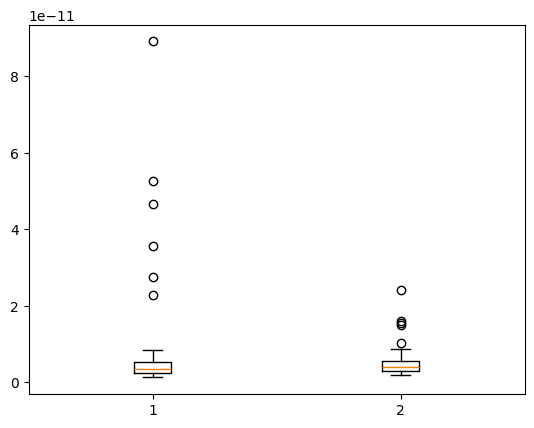

In [36]:
plt.boxplot(delta_mat)

In [12]:
#calculation of theta band powers for both SD data
from tqdm import tqdm_notebook
theta_power_SD_list=[]
for datta in tqdm_notebook(data_SD):
    ith_theta_powers_SD = average_bandpower_theta(datta, fs=500, axis=-1)
    theta_power_SD_list.append(ith_theta_powers_SD)

theta_power_SD=np.array(theta_power_SD_list)
theta_power_SD.shape

C:\Users\suvan\AppData\Local\Temp\ipykernel_11812\1712000823.py:4: TqdmDeprecationWarning: This function will be removed in tqdm==5.0.0
Please use `tqdm.notebook.tqdm` instead of `tqdm.tqdm_notebook`
  for datta in tqdm_notebook(data_SD):


  0%|          | 0/66 [00:00<?, ?it/s]

(66,)

In [13]:
#calculation of theta band powers for both NS data
from tqdm import tqdm_notebook
theta_power_NS_list=[]
for datta in tqdm_notebook(data_NS):
    ith_theta_powers_NS = average_bandpower_theta(datta, fs=500, axis=-1)
    theta_power_NS_list.append(ith_theta_powers_NS)

theta_power_NS=np.array(theta_power_NS_list)
theta_power_NS.shape

C:\Users\suvan\AppData\Local\Temp\ipykernel_11812\1106825402.py:4: TqdmDeprecationWarning: This function will be removed in tqdm==5.0.0
Please use `tqdm.notebook.tqdm` instead of `tqdm.tqdm_notebook`
  for datta in tqdm_notebook(data_NS):


  0%|          | 0/66 [00:00<?, ?it/s]

(66,)

In [14]:
#calculation of alpha band powers for both SD data
from tqdm import tqdm_notebook
alpha_power_SD_list=[]
for datta in tqdm_notebook(data_SD):
    ith_alpha_powers_SD = average_bandpower_alpha(datta, fs=500, axis=-1)
    alpha_power_SD_list.append(ith_alpha_powers_SD)

alpha_power_SD=np.array(alpha_power_SD_list)
alpha_power_SD.shape

C:\Users\suvan\AppData\Local\Temp\ipykernel_11812\779348607.py:4: TqdmDeprecationWarning: This function will be removed in tqdm==5.0.0
Please use `tqdm.notebook.tqdm` instead of `tqdm.tqdm_notebook`
  for datta in tqdm_notebook(data_SD):


  0%|          | 0/66 [00:00<?, ?it/s]

(66,)

In [15]:
#calculation of alpha band powers for both NS data
from tqdm import tqdm_notebook
alpha_power_NS_list=[]
for datta in tqdm_notebook(data_NS):
    ith_alpha_powers_NS = average_bandpower_alpha(datta, fs=500, axis=-1)
    alpha_power_NS_list.append(ith_alpha_powers_NS)

alpha_power_NS=np.array(alpha_power_NS_list)
alpha_power_NS.shape

C:\Users\suvan\AppData\Local\Temp\ipykernel_11812\869701482.py:4: TqdmDeprecationWarning: This function will be removed in tqdm==5.0.0
Please use `tqdm.notebook.tqdm` instead of `tqdm.tqdm_notebook`
  for datta in tqdm_notebook(data_NS):


  0%|          | 0/66 [00:00<?, ?it/s]

(66,)

In [16]:
#calculation of beta band powers for both SD data
from tqdm import tqdm_notebook
beta_power_SD_list=[]
for datta in tqdm_notebook(data_SD):
    ith_beta_powers_SD = average_bandpower_beta(datta, fs=500, axis=-1)
    beta_power_SD_list.append(ith_beta_powers_SD)

beta_power_SD=np.array(beta_power_SD_list)
beta_power_SD.shape

C:\Users\suvan\AppData\Local\Temp\ipykernel_11812\1461013804.py:4: TqdmDeprecationWarning: This function will be removed in tqdm==5.0.0
Please use `tqdm.notebook.tqdm` instead of `tqdm.tqdm_notebook`
  for datta in tqdm_notebook(data_SD):


  0%|          | 0/66 [00:00<?, ?it/s]

(66,)

In [17]:
#calculation of beta band powers for NS data
from tqdm import tqdm_notebook
beta_power_NS_list=[]
for datta in tqdm_notebook(data_NS):
    ith_beta_powers_NS = average_bandpower_beta(datta, fs=500, axis=-1)
    beta_power_NS_list.append(ith_beta_powers_NS)

beta_power_NS=np.array(beta_power_NS_list)
beta_power_NS.shape

C:\Users\suvan\AppData\Local\Temp\ipykernel_11812\577999874.py:4: TqdmDeprecationWarning: This function will be removed in tqdm==5.0.0
Please use `tqdm.notebook.tqdm` instead of `tqdm.tqdm_notebook`
  for datta in tqdm_notebook(data_NS):


  0%|          | 0/66 [00:00<?, ?it/s]

(66,)

In [18]:
#calculation of gamma band powers for SD data
from tqdm import tqdm_notebook
gamma_power_SD_list=[]
for datta in tqdm_notebook(data_SD):
    ith_gamma_powers_SD = average_bandpower_gamma(datta, fs=500, axis=-1)
    gamma_power_SD_list.append(ith_gamma_powers_SD)

gamma_power_SD=np.array(gamma_power_SD_list)
gamma_power_SD.shape

C:\Users\suvan\AppData\Local\Temp\ipykernel_11812\2492538184.py:4: TqdmDeprecationWarning: This function will be removed in tqdm==5.0.0
Please use `tqdm.notebook.tqdm` instead of `tqdm.tqdm_notebook`
  for datta in tqdm_notebook(data_SD):


  0%|          | 0/66 [00:00<?, ?it/s]

(66,)

In [19]:
#calculation of gamma band powers for NS data
from tqdm import tqdm_notebook
gamma_power_NS_list=[]
for datta in tqdm_notebook(data_NS):
    ith_gamma_powers_NS = average_bandpower_gamma(datta, fs=500, axis=-1)
    gamma_power_NS_list.append(ith_gamma_powers_NS)

gamma_power_NS=np.array(gamma_power_NS_list)
gamma_power_NS.shape

C:\Users\suvan\AppData\Local\Temp\ipykernel_11812\3490992863.py:4: TqdmDeprecationWarning: This function will be removed in tqdm==5.0.0
Please use `tqdm.notebook.tqdm` instead of `tqdm.tqdm_notebook`
  for datta in tqdm_notebook(data_NS):


  0%|          | 0/66 [00:00<?, ?it/s]

(66,)

## Absolute Powers

In [20]:
from scipy import stats
from statsmodels.stats.weightstats import ztest

In [29]:
t_stat_delta, p_delta_t = stats.ttest_rel(delta_power_SD, delta_power_NS)
z_stat_delta, p_delta_z = ztest(delta_power_SD, delta_power_NS, value=0)
print("DELTA: \n","T_stat:\n", t_stat_delta,"\n","P_stat:\n", p_delta_t,"\n Z_stat:\n", z_stat_delta,"\n p_stat:\n", p_delta_z)

DELTA: 
 T_stat:
 -1.3804102099800168 
 P_stat:
 0.17218929377072595 
 Z_stat:
 -1.403577080288998 
 p_stat:
 0.16044482411309868


In [30]:
t_stat_theta, p_theta_t = stats.ttest_rel(theta_power_SD, theta_power_NS)
z_stat_theta, p_theta_z = ztest(theta_power_SD, theta_power_NS, value=0)
print("THETA: \n","T_stat:\n", t_stat_theta,"\n","P_stat:\n", p_theta_t,"\n Z_stat:\n", z_stat_theta,"\n p_stat:\n", p_theta_z)

THETA: 
 T_stat:
 0.2901257654830913 
 P_stat:
 0.7726435892813758 
 Z_stat:
 0.22608574080726968 
 p_stat:
 0.8211347346748629


In [32]:
t_stat_alpha, p_alpha_t = stats.ttest_rel(alpha_power_SD, alpha_power_NS)
z_stat_alpha, p_alpha_z = ztest(alpha_power_SD, alpha_power_NS, value=0)
print("ALPHA: \n","T_stat:\n", t_stat_alpha,"\n","P_stat:\n", p_alpha_t,"\n Z_stat:\n", z_stat_alpha,"\n p_stat:\n", p_alpha_z)

ALPHA: 
 T_stat:
 -0.6604627417765635 
 P_stat:
 0.51129083353915 
 Z_stat:
 -0.4855222061219354 
 p_stat:
 0.6273059646458311


In [33]:
t_beta, p_beta_t = stats.ttest_rel(beta_power_SD, beta_power_NS)
z_beta, p_beta_z = ztest(beta_power_SD, beta_power_NS, value=0)
print("BETA: \n","T_stat:\n", t_beta,"\n","P_stat:\n", p_beta_t,"\n Z_stat:\n", z_beta,"\n p_stat:\n", p_beta_z)

BETA: 
 T_stat:
 0.6782678268643194 
 P_stat:
 0.500009510313012 
 Z_stat:
 0.3558749875381474 
 p_stat:
 0.721934188203772


In [34]:
t_gamma, p_gamma_t = stats.ttest_rel(gamma_power_SD, gamma_power_NS)
z_gamma, p_gamma_z = ztest(gamma_power_SD, gamma_power_NS, value=0)
print("GAMMA: \n","T_stat:\n", t_gamma,"\n","P_stat:\n", p_gamma_t,"\n Z_stat:\n", z_gamma,"\n p_stat:\n", p_gamma_z)

GAMMA: 
 T_stat:
 0.06556204979929275 
 P_stat:
 0.947927734650893 
 Z_stat:
 0.03679856900240111 
 p_stat:
 0.9706456150479258


In [26]:
from tqdm import tqdm_notebook
total_power_SD_list=[]
for datta in tqdm_notebook(data_SD):
    ith_total_powers_SD = average_bandpower_total(datta, fs=500)
    total_power_SD_list.append(ith_total_powers_SD)

total_power_SD=np.array(total_power_SD_list)
total_power_SD.shape

C:\Users\suvan\AppData\Local\Temp\ipykernel_15388\3012449440.py:3: TqdmDeprecationWarning: This function will be removed in tqdm==5.0.0
Please use `tqdm.notebook.tqdm` instead of `tqdm.tqdm_notebook`
  for datta in tqdm_notebook(data_SD):


  0%|          | 0/4915 [00:00<?, ?it/s]

(4915,)

In [27]:
from tqdm import tqdm_notebook
total_power_NS_list=[]
for datta in tqdm_notebook(data_NS):
    ith_total_powers_NS = average_bandpower_total(datta, fs=500)
    total_power_NS_list.append(ith_total_powers_NS)

total_power_NS=np.array(total_power_NS_list)
total_power_NS.shape

C:\Users\suvan\AppData\Local\Temp\ipykernel_15388\1690668217.py:3: TqdmDeprecationWarning: This function will be removed in tqdm==5.0.0
Please use `tqdm.notebook.tqdm` instead of `tqdm.tqdm_notebook`
  for datta in tqdm_notebook(data_NS):


  0%|          | 0/4915 [00:00<?, ?it/s]

(4915,)

In [28]:
t_stat_total, p_total_t = stats.ttest_ind(total_power_SD, total_power_NS, equal_var=False)
z_stat_total, p_total_z = ztest(total_power_SD, total_power_NS, value=0)
print("TOTAL: \n","T_stat:\n", t_stat_total,"\n","P_stat:\n", p_total_t,"\n Z_stat:\n", z_stat_total,"\n p_stat:\n", p_total_z)

TOTAL: 
 T_stat:
 -3.358050214318825 
 P_stat:
 0.0007882770229006737 
 Z_stat:
 -3.358050214318825 
 p_stat:
 0.000784943523696224


## Relative Powers

In [29]:
t_stat_delta, p_delta_t = stats.ttest_ind(delta_power_SD / total_power_SD, delta_power_NS / total_power_NS, equal_var=False)
z_stat_delta, p_delta_z = ztest(delta_power_SD / total_power_SD, delta_power_NS / total_power_NS, value=0)
print("DELTA: \n","T_stat:\n", t_stat_delta,"\n","P_stat:\n", p_delta_t,"\n Z_stat:\n", z_stat_delta,"\n p_stat:\n", p_delta_z)

DELTA: 
 T_stat:
 -5.5060185446292 
 P_stat:
 3.765504796744578e-08 
 Z_stat:
 -5.5060185446292 
 p_stat:
 3.67039882809161e-08


In [30]:
t_stat_theta, p_theta_t = stats.ttest_ind(theta_power_SD / total_power_SD, theta_power_NS / total_power_NS, equal_var=False)
z_stat_theta, p_theta_z = ztest(theta_power_SD / total_power_SD, theta_power_NS / total_power_NS, value=0)
print("THETA: \n","T_stat:\n", t_stat_theta,"\n","P_stat:\n", p_theta_t,"\n Z_stat:\n", z_stat_theta,"\n p_stat:\n", p_theta_z)

THETA: 
 T_stat:
 14.176271338513821 
 P_stat:
 3.8434232738542456e-45 
 Z_stat:
 14.176271338513821 
 p_stat:
 1.284947997954452e-45


In [31]:
t_stat_alpha, p_alpha_t = stats.ttest_ind(alpha_power_SD / total_power_SD, alpha_power_NS / total_power_NS, equal_var=False)
z_stat_alpha, p_alpha_z = ztest(alpha_power_SD / total_power_SD, alpha_power_NS / total_power_NS, value=0)
print("ALPHA: \n","T_stat:\n", t_stat_alpha,"\n","P_stat:\n", p_alpha_t,"\n Z_stat:\n", z_stat_alpha,"\n p_stat:\n", p_alpha_z)

ALPHA: 
 T_stat:
 -3.5444502825305175 
 P_stat:
 0.00039529203497791786 
 Z_stat:
 -3.544450282530517 
 p_stat:
 0.00039343269756758614


In [32]:
t_stat_alpha, p_alpha_t = stats.ttest_ind(beta_power_SD / total_power_SD, beta_power_NS / total_power_NS, equal_var=False)
z_stat_alpha, p_alpha_z = ztest(beta_power_SD / total_power_SD, beta_power_NS / total_power_NS, value=0)
print("BETA: \n","T_stat:\n", t_stat_alpha,"\n","P_stat:\n", p_alpha_t,"\n Z_stat:\n", z_stat_alpha,"\n p_stat:\n", p_alpha_z)

BETA: 
 T_stat:
 0.8612318235295608 
 P_stat:
 0.38913140264501456 
 Z_stat:
 0.8612318235295608 
 p_stat:
 0.3891103761335233


In [33]:
t_stat_alpha, p_alpha_t = stats.ttest_ind(gamma_power_SD / total_power_SD, gamma_power_NS / total_power_NS, equal_var=False)
z_stat_alpha, p_alpha_z = ztest(gamma_power_SD / total_power_SD, gamma_power_NS / total_power_NS, value=0)
print("GAMMA: \n","T_stat:\n", t_stat_alpha,"\n","P_stat:\n", p_alpha_t,"\n Z_stat:\n", z_stat_alpha,"\n p_stat:\n", p_alpha_z)

GAMMA: 
 T_stat:
 2.185209322638961 
 P_stat:
 0.02889703254708356 
 Z_stat:
 2.185209322638961 
 p_stat:
 0.028873502287895744
